# Load Scale Recalibration, Proof of Concept

Derives `load_options.scale` (see `scripts/build_demand_profiles.py`, where it's applied as `el_load["Electricity demand"] *= scale`) from Ember reference demand, instead of hand tuning it as has been done so far (`config.zm.valid_2023.yaml` currently has `scale: 1.25`, derived informally and undocumented).

If the approach holds up, the logic here is the candidate to promote into a proper rule (mirroring the existing `build_reference_generation` rule in `rules/postprocessing.smk`) later.

**Data source**: `data/validation/ember_yearly_electricity_data.csv`, Ember's "Yearly Electricity Data" (generation-oriented) release. For a given country/year, the demand figure is the row where `Electricity source == "Demand"`; its value is stored under the `Generation (TWh)` column, which Ember reuses across every `Electricity source` row (generation, net imports, demand, ...).

In [1]:
import os

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import cartopy.crs as ccrs
from pathlib import Path
import pypsa
import logging
import networkx as nx
logging.getLogger("pypsa.contingency").setLevel(logging.ERROR)

ERROR 1: PROJ: proj_create_from_database: Open of /home/mwiche/anaconda3/envs/pypsa-earth/share/proj failed


## Parameters

Edit these to calibrate a different year / resolution / scenario. All `dispatch_validation` scenarios (2020–2024) can reuse this notebook by changing `YEAR` and `RUN_NAME`.

In [2]:
YEAR = 2023
COUNTRY_ISO3 = "ZMB"

PYPSA_ZAMBIA_DIR = "/home/mwiche/pypsa-zambia"

RUN_NAME = "validation_dispatch_zambia_2023"
DEMAND_PROFILES_PATH = f"{PYPSA_ZAMBIA_DIR}/resources/{RUN_NAME}/demand_profiles.csv"

# Scale the demand_profiles.csv above was actually built with — check
# logs/<run_name>/build_demand_profiles.log for "Load data scaled with scaling
# factor X.". Set to 1.0 once you rebuild the profile cleanly with
# load_options.scale: 1.0, which is the recommended way to get a final number.
CURRENT_SCALE = 0.9

EMBER_RAW_PATH = f"{PYPSA_ZAMBIA_DIR}/data/validation/ember_yearly_electricity_data.csv"


## 1. Reference demand (Ember)

Parsed directly from the raw release: filter to the country, then to the `"Demand"` pseudo-source row per year.

In [3]:
ember_raw = pd.read_csv(EMBER_RAW_PATH)

reference_table = (
    ember_raw[
        (ember_raw["ISO 3 code"] == COUNTRY_ISO3)
        & (ember_raw["Electricity source"] == "Demand")
    ][["Year", "Generation (TWh)"]]
    .rename(columns={"Year": "year", "Generation (TWh)": "demand_twh"})
    .sort_values("year")
    .reset_index(drop=True)
)

assert not reference_table.empty, f"No Ember demand rows found for {COUNTRY_ISO3}"

reference_demand_twh = float(
    reference_table.loc[reference_table["year"] == YEAR, "demand_twh"].iloc[0]
)
print(f"Ember reference demand, {COUNTRY_ISO3} {YEAR}: {reference_demand_twh:.3f} TWh")
reference_table.tail()

Ember reference demand, ZMB 2023: 16.090 TWh


,year,demand_twh
20,2020,14.02
21,2021,15.59
22,2022,16.43
23,2023,16.09
24,2024,16.60


## 2. Modelled demand at scale=1.0

`demand_profiles.csv` is hourly MW per bus, so summing it and dividing by 1e6 gives annual TWh. It's then un-scaled back to what `scale=1.0` would have produced.

In [4]:
demand_profiles = pd.read_csv(DEMAND_PROFILES_PATH, index_col=0)

total_demand_twh = demand_profiles.sum().sum() / 1e6  # hourly resolution: MW * 1h = MWh
baseline_demand_twh = total_demand_twh / CURRENT_SCALE

print(f"Model demand as built (scale={CURRENT_SCALE}): {total_demand_twh:.3f} TWh")
print(
    f"Model demand backed out to scale=1.0: {baseline_demand_twh:.3f} TWh"
)

Model demand as built (scale=0.9): 14.318 TWh
Model demand backed out to scale=1.0: 15.909 TWh


## 3. Recommended scale

In [5]:
recommended_scale = reference_demand_twh / baseline_demand_twh
print(f"Recommended load_options.scale for {YEAR}: {recommended_scale:.4f}")

Recommended load_options.scale for 2023: 1.0114


## 4. Sanity check plot

Ember's demand trend over time, with the model's current (uncalibrated) and recalibrated points for `YEAR` overlaid.

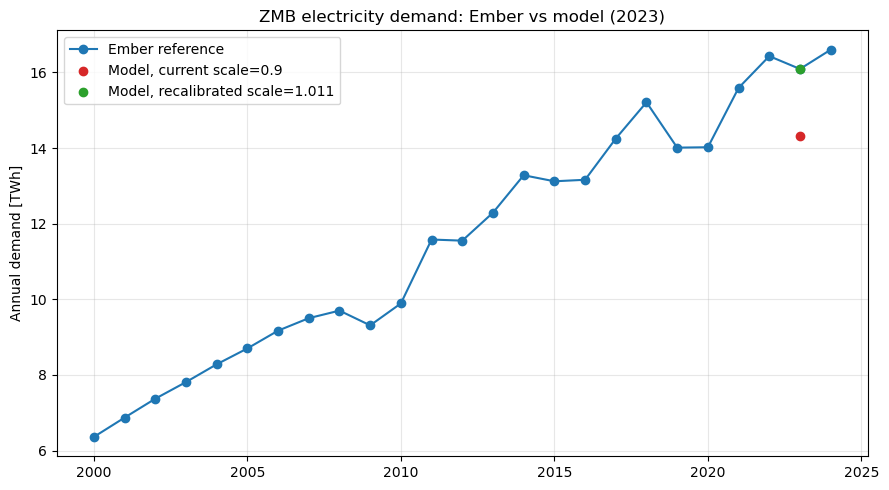

In [6]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(
    reference_table["year"],
    reference_table["demand_twh"],
    marker="o",
    label="Ember reference",
    color="#1f77b4",
)
ax.scatter(
    [YEAR],
    [baseline_demand_twh * CURRENT_SCALE],
    color="#d62728",
    zorder=5,
    label=f"Model, current scale={CURRENT_SCALE}",
)
ax.scatter(
    [YEAR],
    [baseline_demand_twh * recommended_scale],
    color="#2ca02c",
    zorder=5,
    label=f"Model, recalibrated scale={recommended_scale:.3f}",
)
ax.set_ylabel("Annual demand [TWh]")
ax.set_title(f"{COUNTRY_ISO3} electricity demand: Ember vs model ({YEAR})")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

## System Operation


In [7]:

_candidates = [
    Path("/home/mwiche/pypsa-zambia/results/validation_dispatch_10_2023/networks/elec_s_22_ec_lv1.0_3h.nc"),
    Path("/home/mwiche/pypsa-zambia/results/validation_dispatch_22_2023/networks/elec_s_22_ec_lv1.0_3h.nc"),
]
network_path = next((p for p in _candidates if p.exists()), _candidates[0])

n = pypsa.Network(str(network_path))
n

INFO:pypsa.io:Imported network elec_s_22_ec_lv1.0_3h.nc has buses, carriers, generators, global_constraints, lines, line_types, loads, storage_units


PyPSA Network
Components:
 - Bus: 22
 - Carrier: 13
 - Generator: 76
 - GlobalConstraint: 1
 - Line: 27
 - Load: 22
 - StorageUnit: 6
Snapshots: 2920

In [8]:
n.statistics()

Optimal Capacity  Installed Capacity  \
Generator   Biomass                  40.00000            40.00000   
            Coal                    330.00000           330.00000   
            Load shedding          3620.05449          3620.05449   
            Oil                     229.60000           229.60000   
            Run of River            138.80000           138.80000   
            Solar                   122.00000           122.00000   
Line        Ac                    18346.47105         18346.47105   
Load        -                         0.00000             0.00000   
StorageUnit Reservoir & Dam        3033.00000          3033.00000   

                                   Supply    Withdrawal  Energy Balance  \
Generator   Biomass          2.986800e+05  0.000000e+00    2.986800e+05   
            Coal             2.466937e+06  0.000000e+00    2.466937e+06   
            Load shedding    5.337292e+06  0.000000e+00    5.337292e+06   
            Oil              1.947703e+06  0.000000e+00    1.947703e+06   
            Run of River     5.265225e+04  0.000000e+00    5.265225e+04   
            Solar            5.077363e+04  0.000000e+00    5.077363e+04   
Line        Ac               4.379026e+07  4.379026e+07    0.000000e+00   
Load        -                0.000000e+00  1.957848e+07   -1.957848e+07   
StorageUnit Reservoir & Dam  9.424447e+06  0.000000e+00    9.424447e+06   

                             Transmission  Capacity Factor   Curtailment  \
Generator   Biomass          0.000000e+00         0.852397  5.172000e+04   
            Coal             0.000000e+00         0.853375  4.238633e+05   
            Load shedding    0.000000e+00         0.168307  2.637439e+07   
            Oil              0.000000e+00         0.968382  6.359309e+04   
            Run of River     0.000000e+00         0.043304  0.000000e+00   
            Solar            0.000000e+00         0.047509  1.266951e+05   
Line        Ac              -7.826701e+06         0.272471  0.000000e+00   
Load        -                0.000000e+00              NaN  0.000000e+00   
StorageUnit Reservoir & Dam  0.000000e+00         0.354715  1.714463e+07   

                             Capital Expenditure  Operational Expenditure  \
Generator   Biomass                 2.487973e+06             1.239319e+06   
            Coal                    2.347685e+07             1.799123e+08   
            Load shedding           0.000000e+00             5.337293e+11   
            Oil                     1.230533e+07             8.259102e+06   
            Run of River            1.303184e+07             5.118571e+02   
            Solar                   8.752193e+06             4.775132e+02   
Line        Ac                      1.214885e+08             0.000000e+00   
Load        -                       0.000000e+00             0.000000e+00   
StorageUnit Reservoir & Dam         0.000000e+00             9.982028e+06   

                                  Revenue   Market Value  
Generator   Biomass          1.417824e+08     474.696675  
            Coal             2.161304e+10    8761.082501  
            Load shedding    5.337293e+11  100000.008984  
            Oil              1.362356e+11   69946.799594  
            Run of River     3.071652e+08    5833.848609  
            Solar            4.478063e+09   88196.566709  
Line        Ac               6.538580e+11   14931.584273  
Load        -               -1.354755e+12            NaN  
StorageUnit Reservoir & Dam  4.391589e+09     465.978397

### Spatial structure

Load Distribution

/home/mwiche/anaconda3/envs/pypsa-earth/lib/python3.11/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


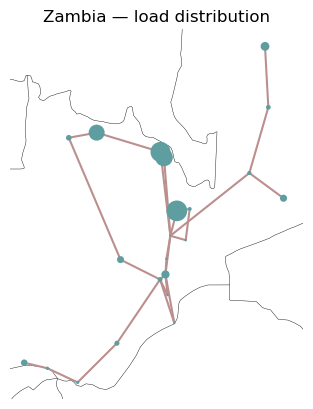

In [9]:
fig, ax = plt.subplots(
    1,
    1,
    subplot_kw={"projection": ccrs.EqualEarth()},
)

load_distribution = n.loads_t.p_set.iloc[0].groupby(n.loads.bus).sum()
n.plot(bus_sizes=load_distribution / 6000, ax=ax, title="Zambia — load distribution");

/home/mwiche/anaconda3/envs/pypsa-earth/lib/python3.11/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/home/mwiche/anaconda3/envs/pypsa-earth/lib/python3.11/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/home/mwiche/anaconda3/envs/pypsa-earth/lib/python3.11/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/home/mwiche/anaconda3/envs/pypsa-earth/lib/python3.11/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/home/mwiche/ana

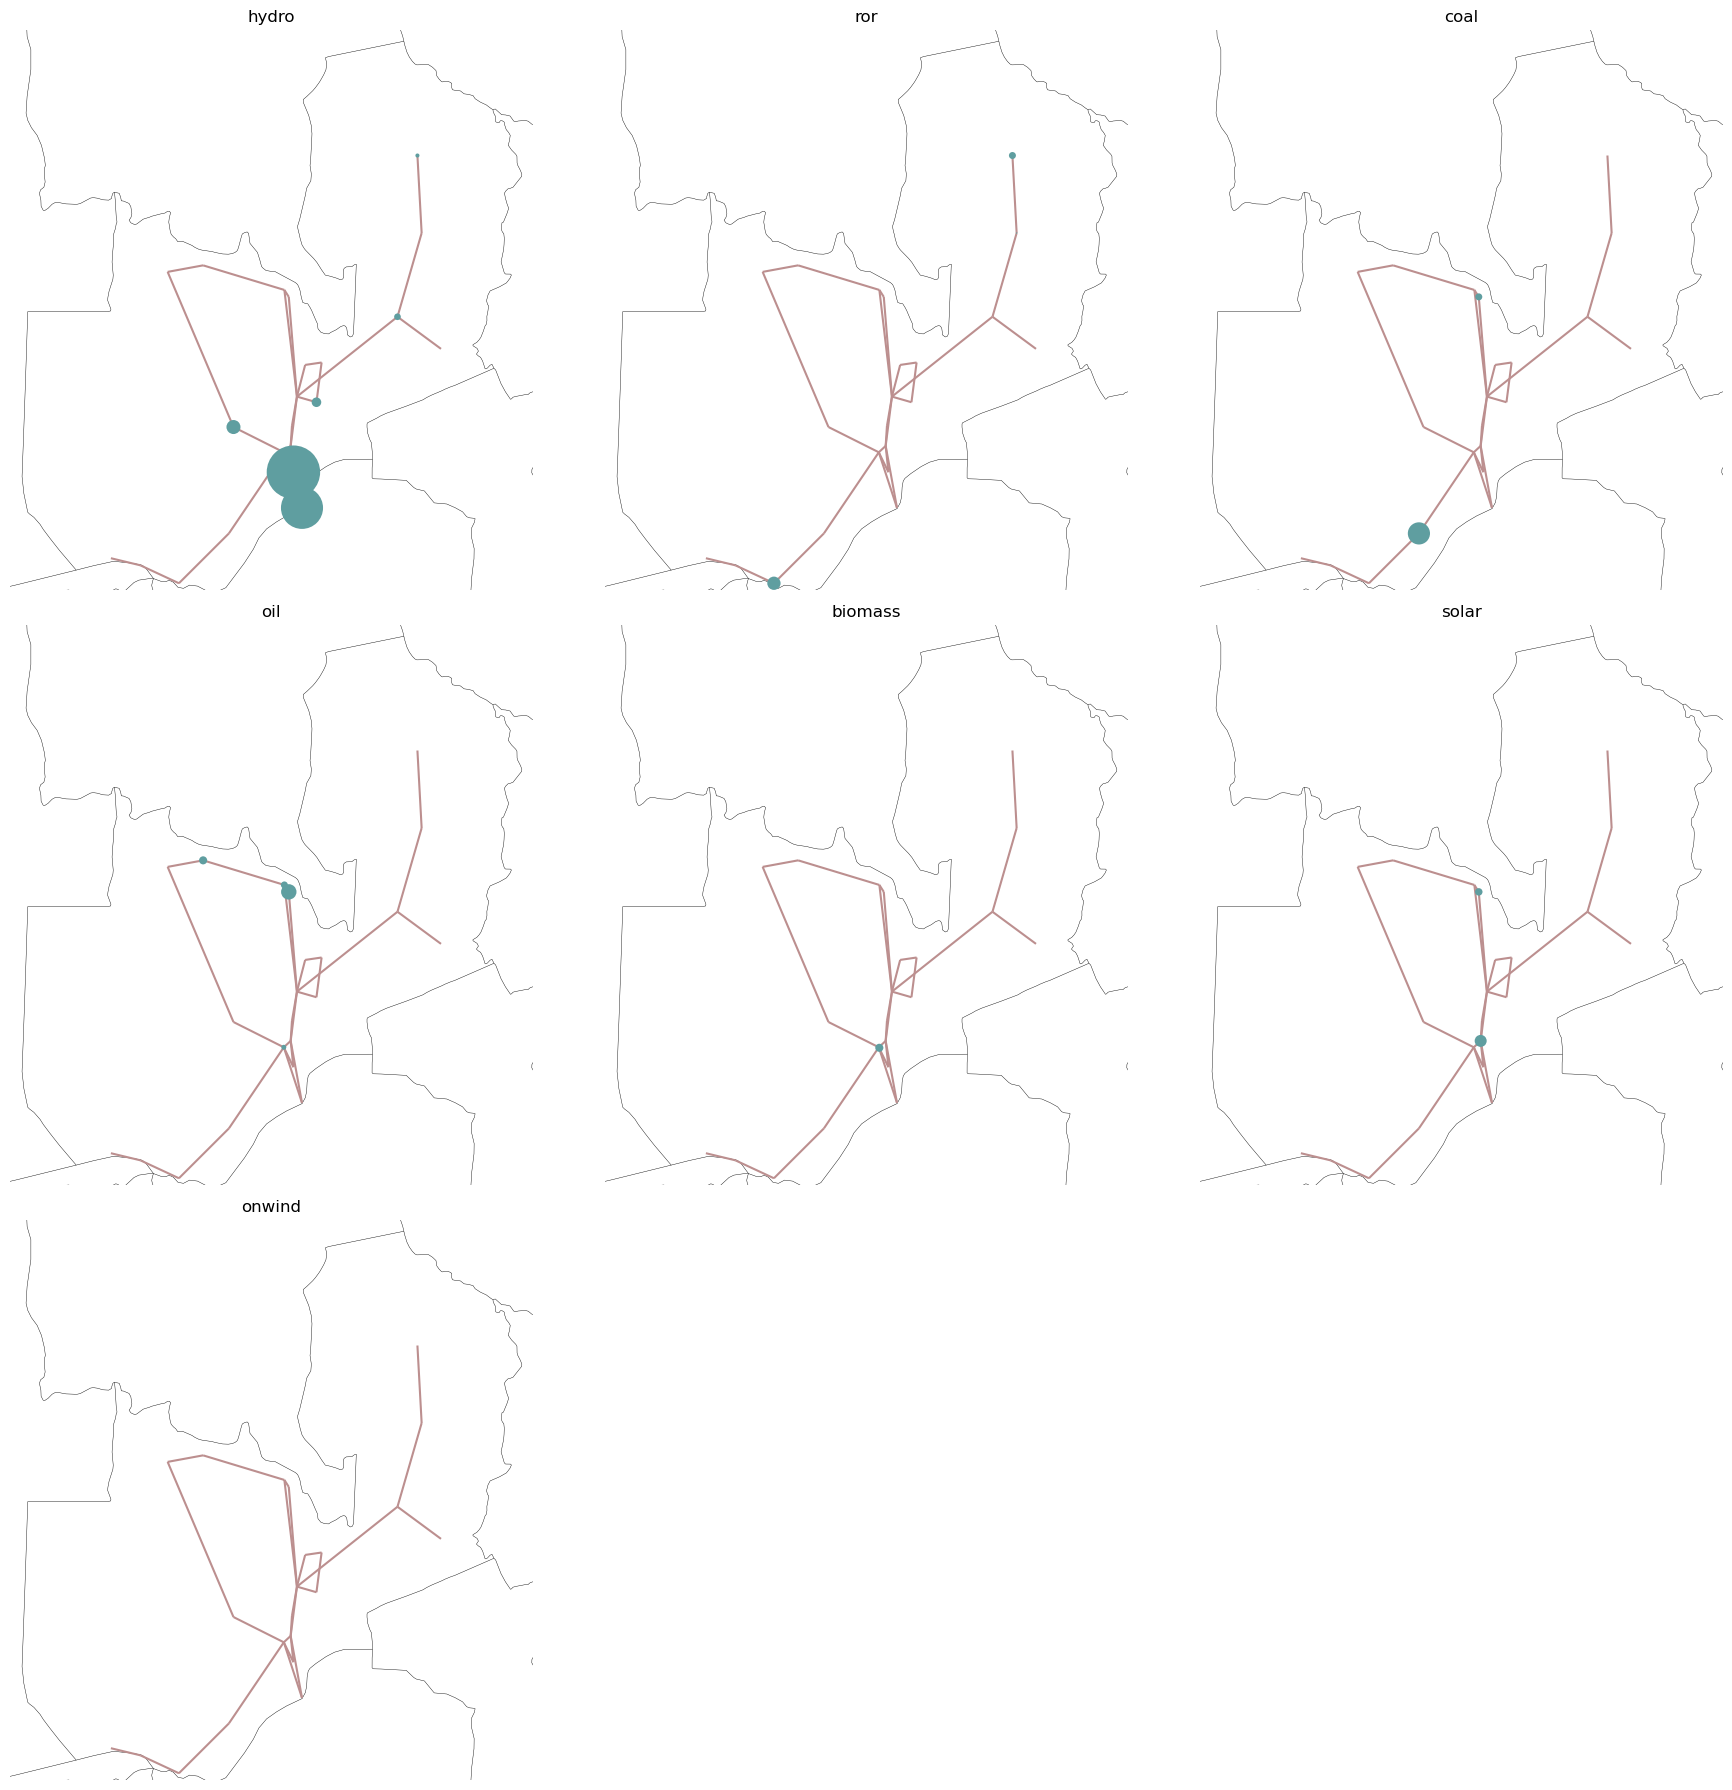

In [10]:
techs = ["hydro", "ror", "coal", "oil", "biomass", "solar", "onwind"]

n_graphs = len(techs)
n_cols = 3
if n_graphs % n_cols == 0:
    n_rows = n_graphs // n_cols
else:
    n_rows = n_graphs // n_cols + 1


fig, axes = plt.subplots(
    nrows=n_rows, ncols=n_cols, subplot_kw={"projection": ccrs.EqualEarth()}
)
size = 6
fig.set_size_inches(size * n_cols, size * n_rows)
axes = axes.flatten()

for i, tech in enumerate(techs):
    ax = axes[i]
    if tech in n.storage_units.carrier.unique():
        units = n.storage_units[n.storage_units.carrier == tech]
    else:
        units = n.generators[n.generators.carrier == tech]
    tech_distribution = (
        units.groupby("bus")["p_nom"].sum().reindex(n.buses.index, fill_value=0)
    )
    n.plot(ax=ax, bus_sizes=tech_distribution / 6000)
    ax.set_title(tech)

    ax.set_extent(
        #[21.5, 34.0, -18.0, -8.0],
        [21.8, 33.8, -18.0, -8.0],
        crs=ccrs.PlateCarree(),
    )    

for j in range(len(techs), len(axes)):
    fig.delaxes(axes[j])

fig.tight_layout()

### Dispatch

In [11]:
gen_dispatch = (
    n.generators_t.p
    .T.groupby(n.generators.carrier)
    .sum()
    .T
)

storage_dispatch = (
    n.storage_units_t.p
    .T.groupby(n.storage_units.carrier)
    .sum()
    .T
)

dispatch = pd.concat(
    [gen_dispatch, storage_dispatch],
    axis=1,
)

In [12]:
dispatch = dispatch.T.groupby(level=0).sum().T

In [13]:
carrier_colors = n.carriers["color"].reindex(dispatch.columns)

In [14]:
carrier_colors["export"] = "orange"

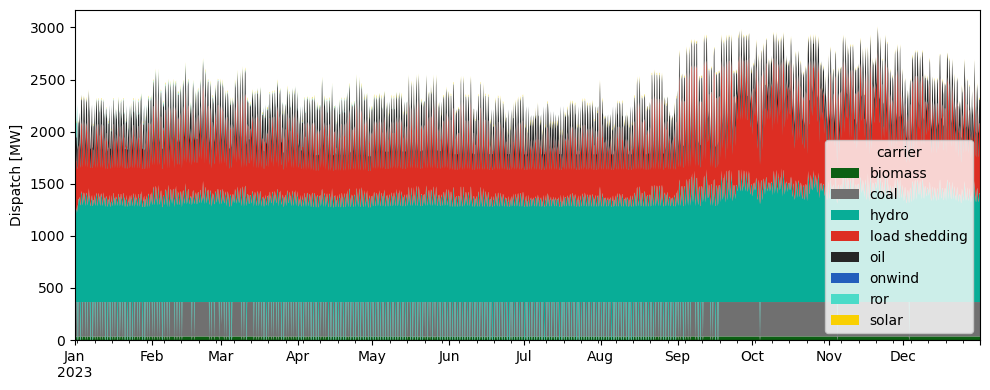

In [15]:
dispatch_pos = dispatch.clip(lower=0)
dispatch_neg = dispatch.clip(upper=0)

fig, ax = plt.subplots(figsize=(10, 4))

dispatch_pos.plot.area(
    ax=ax,
    color=carrier_colors,    
    stacked=True,
    linewidth=0,
)

dispatch_neg.plot.area(
    ax=ax,
    stacked=True,
    linewidth=0,
    legend=False,
)

ax.axhline(0, color="k", linewidth=0.8)
ax.set_ylabel("Dispatch [MW]")
ax.set_xlabel("")

plt.tight_layout()

### Load Shedding

Where and when demand goes unserved. `n.generators` includes a `"load shedding"` carrier per bus (see `get_load_shedding_capacity` in `scripts/solve_network.py`) 

In [16]:
load_shedding_gens = n.generators[n.generators.carrier == "load shedding"].index
load_shedding_dispatch = n.generators_t.p[load_shedding_gens].copy()
load_shedding_dispatch.columns = n.generators.loc[load_shedding_gens, "bus"]

load_shedding_energy_by_bus = (
    load_shedding_dispatch.multiply(n.snapshot_weightings.generators, axis=0).sum() / 1e3
).sort_values(ascending=False)
load_shedding_energy_by_bus = load_shedding_energy_by_bus[load_shedding_energy_by_bus > 0]

network_demand_twh = (
    n.loads_t.p_set.multiply(n.snapshot_weightings.objective, axis=0).sum().sum() / 1e6
)
total_shed_twh = load_shedding_energy_by_bus.sum() / 1e3

print(f"Buses with load shedding: {len(load_shedding_energy_by_bus)} / {len(n.buses)}")
print(f"Total load shed: {total_shed_twh:.3f} TWh ({100 * total_shed_twh / network_demand_twh:.1f}% of demand)")


Buses with load shedding: 7 / 22
Total load shed: 5.337 TWh (27.3% of demand)


Load shed by bus, ranked shows whether shedding is concentrated at a few buses or spread across the network.

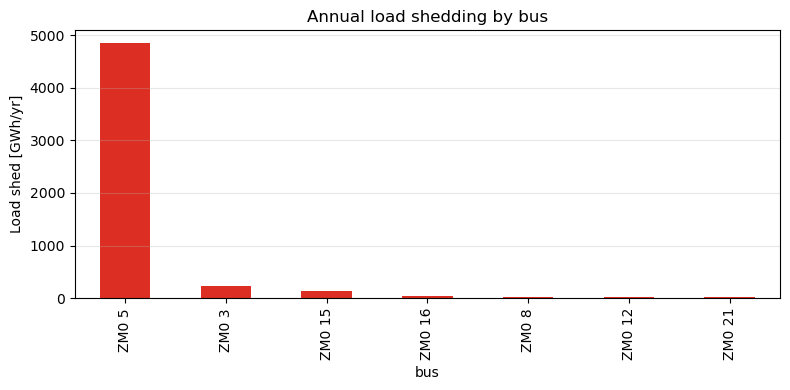

In [17]:
fig, ax = plt.subplots(figsize=(8, 4))
load_shedding_energy_by_bus.plot.bar(ax=ax, color="#dd2e23")
ax.set_ylabel("Load shed [GWh/yr]")
ax.set_title("Annual load shedding by bus")
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()

Same thing, spatially, bubble size is annual load shed at that bus.

/home/mwiche/anaconda3/envs/pypsa-earth/lib/python3.11/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


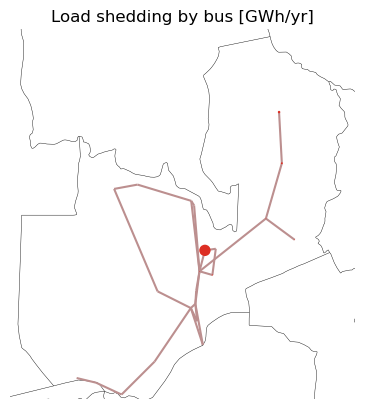

In [18]:
fig, ax = plt.subplots(subplot_kw={"projection": ccrs.EqualEarth()})

shed_sizes = load_shedding_energy_by_bus.reindex(n.buses.index, fill_value=0)
scale = shed_sizes.max() / 0.03 if shed_sizes.max() > 0 else 1
n.plot(bus_sizes=shed_sizes / scale, ax=ax, bus_colors="#dd2e23", title="Load shedding by bus [GWh/yr]")
ax.set_extent([21.8, 33.8, -18.0, -8.0], crs=ccrs.PlateCarree())

And over time, per bus useful for spotting whether shedding is a persistent shortfall or concentrated in specific periods (e.g. dry-season hydro drawdown).

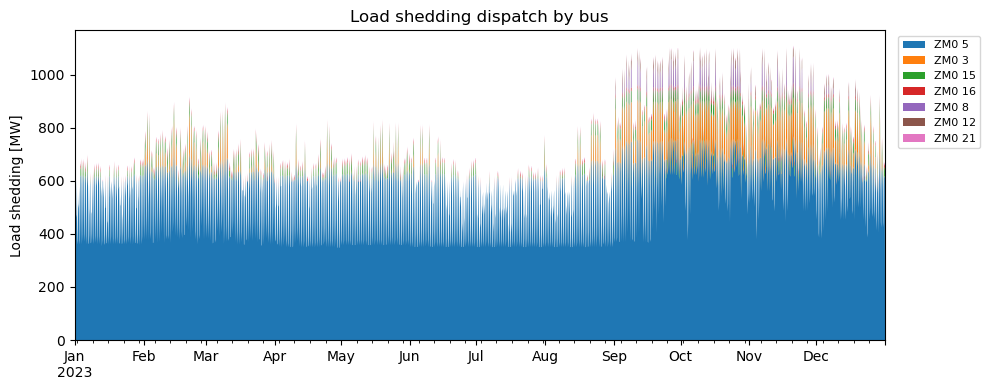

In [19]:
fig, ax = plt.subplots(figsize=(10, 4))
load_shedding_dispatch.loc[:, load_shedding_energy_by_bus.index].plot.area(
    ax=ax, stacked=True, linewidth=0
)
ax.set_ylabel("Load shedding [MW]")
ax.set_xlabel("")
ax.set_title("Load shedding dispatch by bus")
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1), fontsize=8)
fig.tight_layout()

### Line Loadings

Utilisation of each line's thermal rating (`s_nom`, already derated by `lines.s_max_pu` in the scenario config) over the year, 

In [20]:
line_loading_pct = n.lines_t.p0.abs().div(n.lines.s_nom, axis=1) * 100
max_loading = line_loading_pct.max()

print("Most-loaded lines (max % of s_nom over the year):")
print(max_loading.sort_values(ascending=False).head(10).round(1))

Most-loaded lines (max % of s_nom over the year):
Line
26    70.0
19    70.0
14    68.1
8     60.4
18    60.1
4     58.7
1     57.0
15    55.0
6     48.8
23    45.5
dtype: float64


Spatially, coloured by max loading over the year.

/home/mwiche/anaconda3/envs/pypsa-earth/lib/python3.11/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


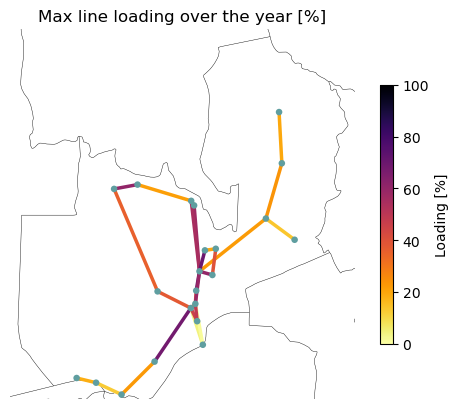

In [21]:
fig, ax = plt.subplots(subplot_kw={"projection": ccrs.EqualEarth()})

n.plot(
    ax=ax,
    bus_sizes=0.01,
    line_widths=2.5,
    line_colors=max_loading,
    line_cmap=plt.cm.inferno_r,
    line_norm=plt.Normalize(vmin=0, vmax=100),
    title="Max line loading over the year [%]",
)
ax.set_extent([21.8, 33.8, -18.0, -8.0], crs=ccrs.PlateCarree())

sm = plt.cm.ScalarMappable(cmap=plt.cm.inferno_r, norm=plt.Normalize(vmin=0, vmax=100))
sm.set_array([])
fig.colorbar(sm, ax=ax, label="Loading [%]", shrink=0.7)

Compare bus sizes in the load-shedding map against line colours here: a bus that sheds load while its incoming lines sit well under 70% points at a local generation shortfall; a bus that sheds load behind consistently near-70% lines points at transmission congestion instead, the two need different fixes.

## Power flow analysis

Bus size is generation + storage discharge, line colour is loading, and arrows show flow direction and magnitude. Adapted from the `plot_network` helper in `operation_demo.ipynb`, reusing the already-loaded `n` and the `load_shedding_dispatch` computed above instead of loading a separate network.

In [32]:
def plot_power_flow(n, snapshot, ax):
    gen_supply = n.generators_t.p.loc[snapshot].groupby(n.generators.bus).sum()
    storage_supply = (
        n.storage_units_t.p.loc[snapshot].clip(lower=0).groupby(n.storage_units.bus).sum()
    )
    bus_size = gen_supply.add(storage_supply, fill_value=0).reindex(n.buses.index, fill_value=0)

    line_loading = n.lines_t.p0.loc[snapshot].abs() / n.lines.s_nom
    line_flows = pd.concat({"Line": n.lines_t.p0.loc[snapshot]})

    n.plot(
        ax=ax,
        bus_sizes=bus_size / 30000,
        line_colors=line_loading,
        line_cmap=plt.cm.inferno_r,
        line_norm=plt.Normalize(vmin=0, vmax=1),
        flow=line_flows / 50,
        title=f"Power flow at {snapshot}",
    )

    loading_sm = plt.cm.ScalarMappable(cmap=plt.cm.inferno_r, norm=plt.Normalize(vmin=0, vmax=1))
    loading_sm.set_array([])
    plt.colorbar(loading_sm, ax=ax, label="Line loading [fraction of s_nom]", shrink=0.6, pad=0.02)


Snapshot shown: the moment of peak system-wide load shedding, so the flow pattern that leads to it is visible directly.

/home/mwiche/anaconda3/envs/pypsa-earth/lib/python3.11/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


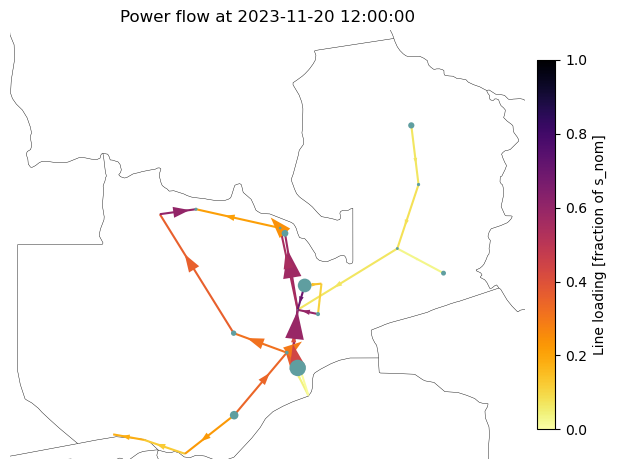

In [33]:
peak_shedding_snapshot = load_shedding_dispatch.sum(axis=1).idxmax()

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={"projection": ccrs.PlateCarree()})
plot_power_flow(n, peak_shedding_snapshot, ax=ax)
ax.set_extent([21.8, 33.8, -18.0, -8.0], crs=ccrs.PlateCarree())
plt.show()

### Comparison: Capacity, Load, and Load Shedding

In [30]:
gen_capacity = n.generators[n.generators.carrier != "load shedding"].groupby("bus").p_nom.sum()
storage_capacity = n.storage_units.groupby("bus").p_nom.sum()
capacity_by_bus = gen_capacity.add(storage_capacity, fill_value=0).reindex(n.buses.index, fill_value=0)

demand_by_bus = (
    n.loads_t.p_set.multiply(n.snapshot_weightings.objective, axis=0).sum() / 1e3
)  # GWh/yr, per load
demand_by_bus = demand_by_bus.groupby(n.loads.bus).sum().reindex(n.buses.index, fill_value=0)

shed_sizes = load_shedding_energy_by_bus.reindex(n.buses.index, fill_value=0)

line_loading_snapshot = n.lines_t.p0.loc[peak_shedding_snapshot].abs() / n.lines.s_nom
line_flows_snapshot = pd.concat({"Line": n.lines_t.p0.loc[peak_shedding_snapshot]})


/home/mwiche/anaconda3/envs/pypsa-earth/lib/python3.11/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/home/mwiche/anaconda3/envs/pypsa-earth/lib/python3.11/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/home/mwiche/anaconda3/envs/pypsa-earth/lib/python3.11/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


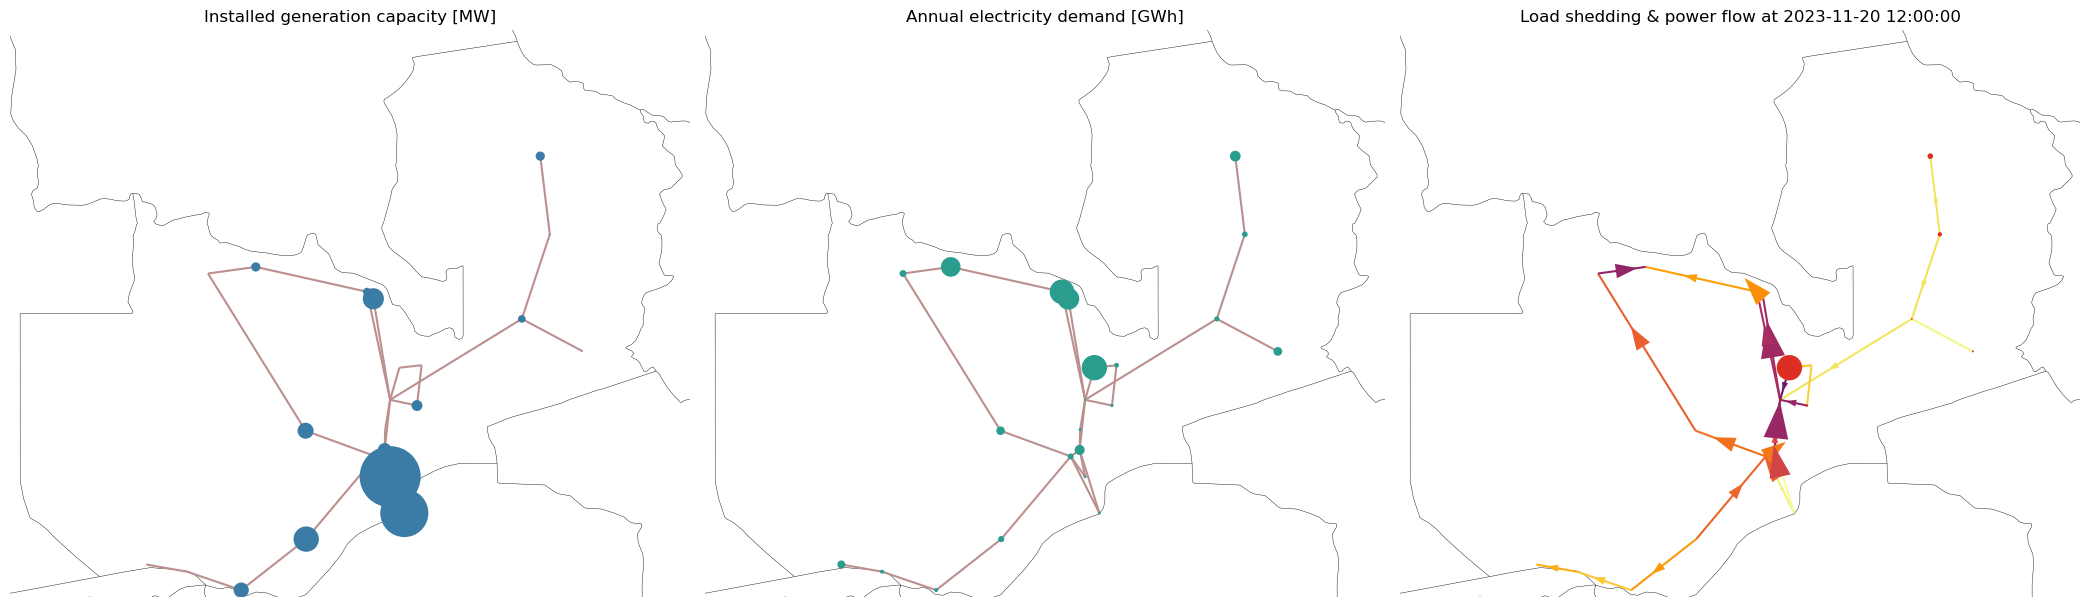

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(21, 7), subplot_kw={"projection": ccrs.PlateCarree()})

n.plot(
    bus_sizes=capacity_by_bus / 6000,
    ax=axes[0],
    bus_colors="#3a7ca5",
    title="Installed generation capacity [MW]",
)

demand_scale = demand_by_bus.max() / 0.05
n.plot(
    bus_sizes=demand_by_bus / demand_scale,
    ax=axes[1],
    bus_colors="#2a9d8f",
    title="Annual electricity demand [GWh]",
)

shed_scale = shed_sizes.max() / 0.05
n.plot(
    ax=axes[2],
    bus_sizes=shed_sizes / shed_scale,
    bus_colors="#dd2e23",
    line_colors=line_loading_snapshot,
    line_cmap=plt.cm.inferno_r,
    line_norm=plt.Normalize(vmin=0, vmax=1),
    flow=line_flows_snapshot / 50,
    title=f"Load shedding & power flow at {peak_shedding_snapshot}",
)

for ax in axes:
    ax.set_extent([21.8, 33.8, -18.0, -8.0], crs=ccrs.PlateCarree())

fig.tight_layout()